# Iowa Historical-Weather and TAIESM Validation

This focused notebook compares packaged Iowa state products over their common
2007-2023 period. It evaluates six population-weighted weather variables plus raw
TELL load, wind capacity factor, and solar capacity factor on identical UTC hours.

Historical weather uses WTK, BC-HRRR, and NSRDB inputs. The long-run comparison
uses `taiesm1_historical_ssp245_v022`. Leap-day hours are removed from the
historical weather series to match the TAIESM no-leap calendar.


## 1. Imports and archived paths

Run this notebook from `notebooks/validation`. It reads only the archived Iowa
weather, load, wind-CF, and solar-CF products needed for this comparison.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path("../../data")
HISTORICAL_DATASET = "wtk_bchrrr_nsrdb_2007_2023"
TAIESM_DATASET = "taiesm1_historical_ssp245_v022_2000_2099"
HISTORICAL_ROOT = DATA_ROOT / HISTORICAL_DATASET
TAIESM_ROOT = DATA_ROOT / TAIESM_DATASET

if not DATA_ROOT.is_dir():
    raise FileNotFoundError("Expected the merged release data at ../../data.")


## 2. Define the shared period and component schemas

The comparison requires exactly 17 x 8,760 hours after calendar alignment.
Dedicated state component files are used instead of loading the much larger
scenario-metrics table.


In [2]:
STATE_ABBR = "IA"
COMPARISON_START = pd.Timestamp("2007-01-01", tz="UTC")
COMPARISON_END = pd.Timestamp("2024-01-01", tz="UTC")
ANALYSIS_YEARS = 17
EXPECTED_HOURS = ANALYSIS_YEARS * 8_760

WEATHER_COLUMNS = [
    "temperature_2m",
    "specifichumidity_2m",
    "windspeed_10m",
    "ghi",
    "relativehumidity_2m",
    "pressure_0m",
]
ENERGY_COLUMNS = ["load_mw", "wind_cf", "solar_cf"]
COMPONENTS = WEATHER_COLUMNS + ENERGY_COLUMNS
COMPONENT_LABELS = {
    "temperature_2m": "2 m temperature",
    "specifichumidity_2m": "2 m specific humidity",
    "windspeed_10m": "10 m wind speed",
    "ghi": "Global horizontal irradiance",
    "relativehumidity_2m": "2 m relative humidity",
    "pressure_0m": "Surface pressure",
    "load_mw": "Raw TELL load",
    "wind_cf": "Wind capacity factor",
    "solar_cf": "Solar capacity factor",
}
COMPONENT_UNITS = {
    "temperature_2m": "degrees C",
    "specifichumidity_2m": "kg/kg",
    "windspeed_10m": "m/s",
    "ghi": "W/m2",
    "relativehumidity_2m": "%",
    "pressure_0m": "Pa",
    "load_mw": "MW",
    "wind_cf": "fraction",
    "solar_cf": "fraction",
}


## 3. Read and align Iowa state weather

Both CSVs must use the exact state-weather schema. String timestamp filtering is
performed while reading chunks, then timestamps are parsed as UTC and leap days
are removed before the two products are aligned.


In [3]:
def read_shared_weather(path):
    chunks = []
    for chunk in pd.read_csv(path, chunksize=250_000):
        if list(chunk.columns) != ["time_utc", *WEATHER_COLUMNS]:
            raise AssertionError(f"Unexpected state-weather schema in {path}.")
        keep = chunk["time_utc"].ge("2007-01-01") & chunk["time_utc"].lt("2024-01-01")
        chunks.append(chunk.loc[keep])

    weather = pd.concat(chunks, ignore_index=True)
    weather["time_utc"] = pd.to_datetime(weather["time_utc"], utc=True)
    leap_day = weather["time_utc"].dt.month.eq(2) & weather["time_utc"].dt.day.eq(29)
    weather = weather.loc[~leap_day].sort_values("time_utc").reset_index(drop=True)
    if weather["time_utc"].duplicated().any():
        raise AssertionError(f"Duplicate Iowa weather timestamps in {path}.")
    return weather


historical_weather_path = HISTORICAL_ROOT / "state_weather" / f"IA_{HISTORICAL_DATASET}_weather.csv"
taiesm_weather_path = TAIESM_ROOT / "state_weather" / f"IA_{TAIESM_DATASET}_weather.csv"
historical_weather = read_shared_weather(historical_weather_path)
taiesm_weather = read_shared_weather(taiesm_weather_path)

if len(historical_weather) != EXPECTED_HOURS or len(taiesm_weather) != EXPECTED_HOURS:
    raise AssertionError("Both Iowa weather products must contain 17 x 8,760 shared hours.")
if not historical_weather["time_utc"].equals(taiesm_weather["time_utc"]):
    raise AssertionError("Historical and TAIESM Iowa weather timestamps do not match.")

display(pd.DataFrame({"product": ["Historical weather", "TAIESM"], "shared_hours": [len(historical_weather), len(taiesm_weather)]}))


,product,shared_hours
0,Historical weather,148920
1,TAIESM,148920


## 4. Read and align Iowa load, wind CF, and solar CF

Each dedicated Parquet is filtered to the same shared period. The three components
are then joined one to one and checked against their corresponding weather hours.


In [4]:
def read_shared_component(path, source_column, output_column):
    filters = [("time_utc", ">=", COMPARISON_START), ("time_utc", "<", COMPARISON_END)]
    frame = pd.read_parquet(path, columns=["time_utc", source_column], filters=filters)
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    leap_day = frame["time_utc"].dt.month.eq(2) & frame["time_utc"].dt.day.eq(29)
    frame = frame.loc[~leap_day].rename(columns={source_column: output_column})
    frame.sort_values("time_utc", inplace=True)
    frame.reset_index(drop=True, inplace=True)
    if len(frame) != EXPECTED_HOURS or frame["time_utc"].duplicated().any():
        raise AssertionError(f"Incomplete or duplicate shared-period rows in {path}.")
    return frame


def read_energy_components(dataset_root, dataset_name):
    load = read_shared_component(
        dataset_root / "state_load" / f"IA_{dataset_name}_load.parquet",
        "load_mw__raw",
        "load_mw",
    )
    wind = read_shared_component(
        dataset_root / "state_wind_cf" / f"IA_{dataset_name}_wind_cf.parquet",
        "wind_cf",
        "wind_cf",
    )
    solar = read_shared_component(
        dataset_root / "state_solar_cf" / f"IA_{dataset_name}_solar_cf.parquet",
        "solar_cf",
        "solar_cf",
    )
    return load.merge(wind, on="time_utc", validate="one_to_one").merge(
        solar, on="time_utc", validate="one_to_one"
    )


historical_energy = read_energy_components(HISTORICAL_ROOT, HISTORICAL_DATASET)
taiesm_energy = read_energy_components(TAIESM_ROOT, TAIESM_DATASET)

historical = historical_weather.merge(historical_energy, on="time_utc", validate="one_to_one")
taiesm = taiesm_weather.merge(taiesm_energy, on="time_utc", validate="one_to_one")
if len(historical) != EXPECTED_HOURS or len(taiesm) != EXPECTED_HOURS:
    raise AssertionError("Weather, load, and CF products must use identical shared hours.")
if not historical["time_utc"].equals(taiesm["time_utc"]):
    raise AssertionError("The two complete Iowa product tables are not timestamp-aligned.")
if historical[COMPONENTS].isna().any().any() or taiesm[COMPONENTS].isna().any().any():
    raise AssertionError("The Iowa comparison contains missing component values.")
for product, frame in [("Historical weather", historical), ("TAIESM", taiesm)]:
    if not frame["wind_cf"].between(-1e-9, 1 + 1e-9).all() or not frame["solar_cf"].between(-1e-9, 1 + 1e-9).all():
        raise AssertionError(f"Capacity factors are outside [0, 1] for {product}.")

coverage = pd.DataFrame(
    {
        "product": ["Historical weather", "TAIESM"],
        "first_hour": [historical["time_utc"].min(), taiesm["time_utc"].min()],
        "last_hour": [historical["time_utc"].max(), taiesm["time_utc"].max()],
        "hours": [len(historical), len(taiesm)],
    }
)
display(coverage)


,product,first_hour,last_hour,hours
0,Historical weather,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,148920
1,TAIESM,2007-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,148920


## 5. Component diagnostics

The table compares central tendency and tails for all nine components. The
hour-aligned RMSE and Pearson correlation summarize point-by-point differences;
the mean absolute quantile difference summarizes distribution-shape differences
over 101 evenly spaced quantiles.


In [5]:
quantile_grid = np.linspace(0.0, 1.0, 101)
diagnostic_rows = []

for component in COMPONENTS:
    reference = historical[component].astype(float)
    candidate = taiesm[component].astype(float)
    reference_quantiles = reference.quantile(quantile_grid).to_numpy()
    candidate_quantiles = candidate.quantile(quantile_grid).to_numpy()
    diagnostic_rows.append(
        {
            "component": component,
            "description": COMPONENT_LABELS[component],
            "units": COMPONENT_UNITS[component],
            "hours": len(reference),
            "historical_mean": reference.mean(),
            "taiesm_mean": candidate.mean(),
            "taiesm_minus_historical_mean": candidate.mean() - reference.mean(),
            "historical_std": reference.std(),
            "taiesm_std": candidate.std(),
            "historical_p01": reference.quantile(0.01),
            "taiesm_p01": candidate.quantile(0.01),
            "historical_median": reference.median(),
            "taiesm_median": candidate.median(),
            "historical_p99": reference.quantile(0.99),
            "taiesm_p99": candidate.quantile(0.99),
            "hour_aligned_rmse": np.sqrt(np.mean(np.square(candidate - reference))),
            "hour_aligned_pearson": reference.corr(candidate),
            "mean_absolute_quantile_difference": np.mean(np.abs(candidate_quantiles - reference_quantiles)),
        }
    )

diagnostics = pd.DataFrame(diagnostic_rows)
if len(diagnostics) != len(COMPONENTS) or not np.isfinite(diagnostics.select_dtypes(include="number").to_numpy()).all():
    raise AssertionError("The Iowa component diagnostic table is incomplete or non-finite.")

display(diagnostics.round(4))


,component,description,units,hours,historical_mean,taiesm_mean,taiesm_minus_historical_mean,historical_std,taiesm_std,historical_p01,taiesm_p01,historical_median,taiesm_median,historical_p99,taiesm_p99,hour_aligned_rmse,hour_aligned_pearson,mean_absolute_quantile_difference
0,temperature_2m,2 m temperature,degrees C,148920,9.8522,8.7959,-1.0563,12.4645,9.2296,-18.5587,-9.3172,10.6734,8.1501,32.1268,27.1630,6.6725,0.8568,3.1954
1,specifichumidity_2m,2 m specific humidity,kg/kg,148920,0.0063,0.0056,-0.0008,0.0054,0.0025,0.0000,0.0018,0.0058,0.0050,0.0195,0.0109,0.0039,0.7577,0.0041
2,windspeed_10m,10 m wind speed,m/s,148920,3.8240,4.5632,0.7392,1.7420,1.2215,1.0745,2.5717,3.5288,4.3529,8.8953,8.2506,2.1137,0.1423,0.8081
3,ghi,Global horizontal irradiance,W/m2,148920,170.8703,163.7726,-7.0978,247.0954,220.7400,0.0000,0.0000,5.5405,35.3143,888.3301,779.8845,114.1782,0.8873,18.3349
4,relativehumidity_2m,2 m relative humidity,%,148920,71.9427,64.8300,-7.1126,18.2472,12.0690,28.7420,37.1120,74.3953,66.6188,103.9733,85.3298,18.2600,0.4445,12.4434
5,pressure_0m,Surface pressure,Pa,148920,98222.6444,88853.1542,-9369.4902,699.9970,379.5093,96452.1188,87820.2959,98206.9996,88883.3275,99972.7698,89721.2022,9402.8366,0.0151,9366.1507
6,load_mw,Raw TELL load,MW,148920,6042.1780,5729.1521,-313.0259,1020.8082,744.9991,4371.0124,4326.5043,5852.0250,5669.0586,9056.4445,7781.5468,727.8123,0.7662,322.1251
7,wind_cf,Wind capacity factor,fraction,148920,0.4594,0.4418,-0.0176,0.3228,0.3251,0.0025,0.0023,0.4244,0.3895,0.9972,0.9993,0.4301,0.1203,0.0180
8,solar_cf,Solar capacity factor,fraction,148920,0.1934,0.1934,0.0000,0.2634,0.2712,0.0000,0.0000,0.0009,0.0001,0.7463,0.7463,0.1829,0.7663,0.0095


## 6. Nine-component duration curves

Each panel uses the same annualized exceedance-hours definition: sorted hourly
values on the x-axis and average hours per year at or above that value on the
y-axis. Solar includes nighttime zeroes.


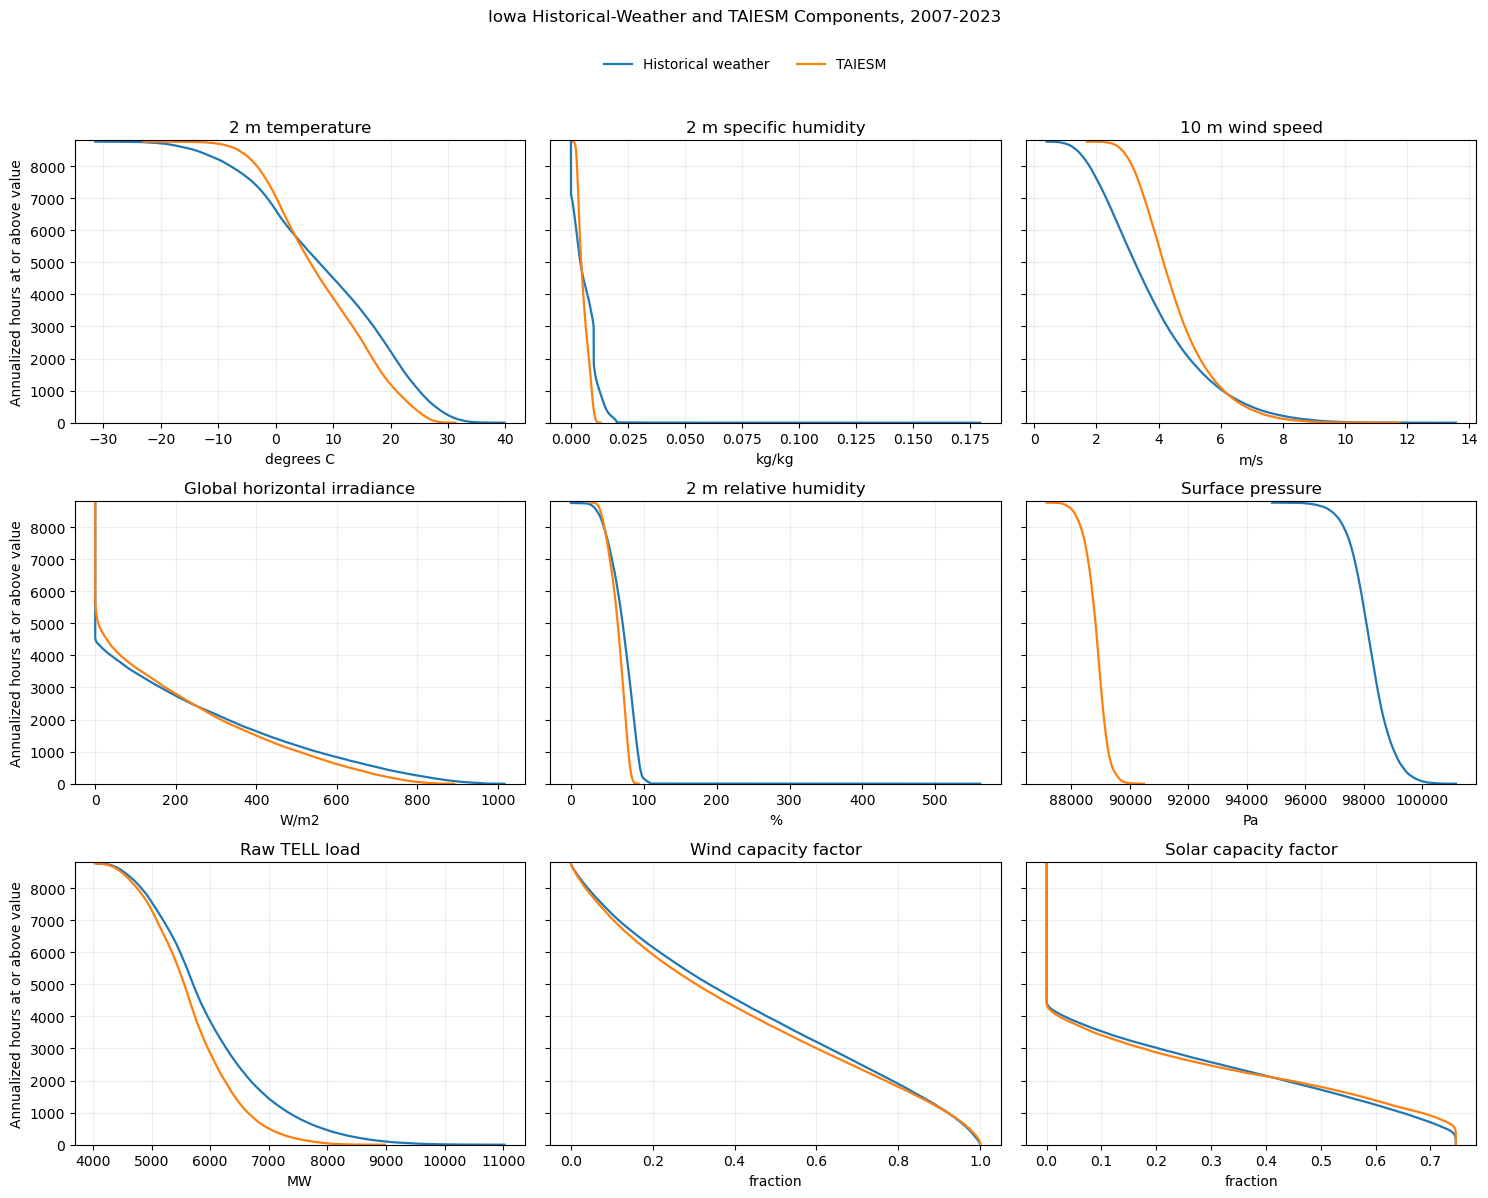

In [6]:
colors = {"Historical weather": "#1f77b4", "TAIESM": "#ff7f0e"}
products = {"Historical weather": historical, "TAIESM": taiesm}

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
for panel_index, (ax, component) in enumerate(zip(axes.flat, COMPONENTS)):
    for product, frame in products.items():
        ordered = np.sort(frame[component].to_numpy(dtype=float))[::-1]
        annualized_exceedance_hours = np.arange(1, len(ordered) + 1) / ANALYSIS_YEARS
        ax.plot(ordered, annualized_exceedance_hours, color=colors[product], linewidth=1.6, label=product)

    ax.set_title(COMPONENT_LABELS[component])
    ax.set_xlabel(COMPONENT_UNITS[component])
    ax.set_ylim(0, 8_800)
    ax.grid(alpha=0.22)
    if panel_index % 3 == 0:
        ax.set_ylabel("Annualized hours at or above value")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle("Iowa Historical-Weather and TAIESM Components, 2007-2023", y=0.995)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


## Interpretation

The diagnostic table quantifies differences in weather forcing and in the three
downstream energy components. The duration curves show whether those differences
are concentrated in distribution tails or persist across typical hours. This is
a shared-period model-product validation; it does not imply that the two weather
products should reproduce the same individual meteorological sequence.
